# 8. Кластеризація DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) — алгоритм кластеризації на основі щільності. На відміну від k-Means, не потребує задання кількості кластерів наперед та здатний виявляти кластери довільної форми. Також автоматично визначає шумові точки (noise).

**Параметри:**
- `eps` — максимальна відстань між двома точками для визнання їх сусідами
- `min_samples` — мінімальна кількість точок для формування щільного регіону

In [1]:
%matplotlib inline

import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd()))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

from src.config import (
    AUDIO_FEATURES, GENRE_COL, PROCESSED_PATH, TOP_PAIRS_PATH,
    RANDOM_STATE, SAMPLE_SIZES, DBSCAN_MIN_SAMPLES,
    RESULTS_DIR, PALETTE
)
from src.data_loader import create_scaled, subsample
from src.visualization import (
    plot_cluster_scatter_2d, plot_k_distance
)
from src.evaluation import compute_metrics, build_results_row, save_results
from src.clustering import (
    run_dbscan, find_best_dbscan_eps, compute_k_distances,
    get_cluster_profiles
)

In [2]:
df = pd.read_csv(PROCESSED_PATH)
with open(TOP_PAIRS_PATH) as f:
    pairs = json.load(f)

n_sample = SAMPLE_SIZES['dbscan']
df_sub = subsample(df, n_sample)
print(f"Дані: {len(df)} записів, підвибірка: {len(df_sub)}")
print(f"Пари для кластеризації: {pairs}")
N = len(pairs)

Дані: 89741 записів, підвибірка: 20000
Пари для кластеризації: [['loudness', 'speechiness'], ['loudness', 'valence'], ['speechiness', 'valence'], ['energy', 'loudness']]


## 8.1 K-distance графіки для вибору eps

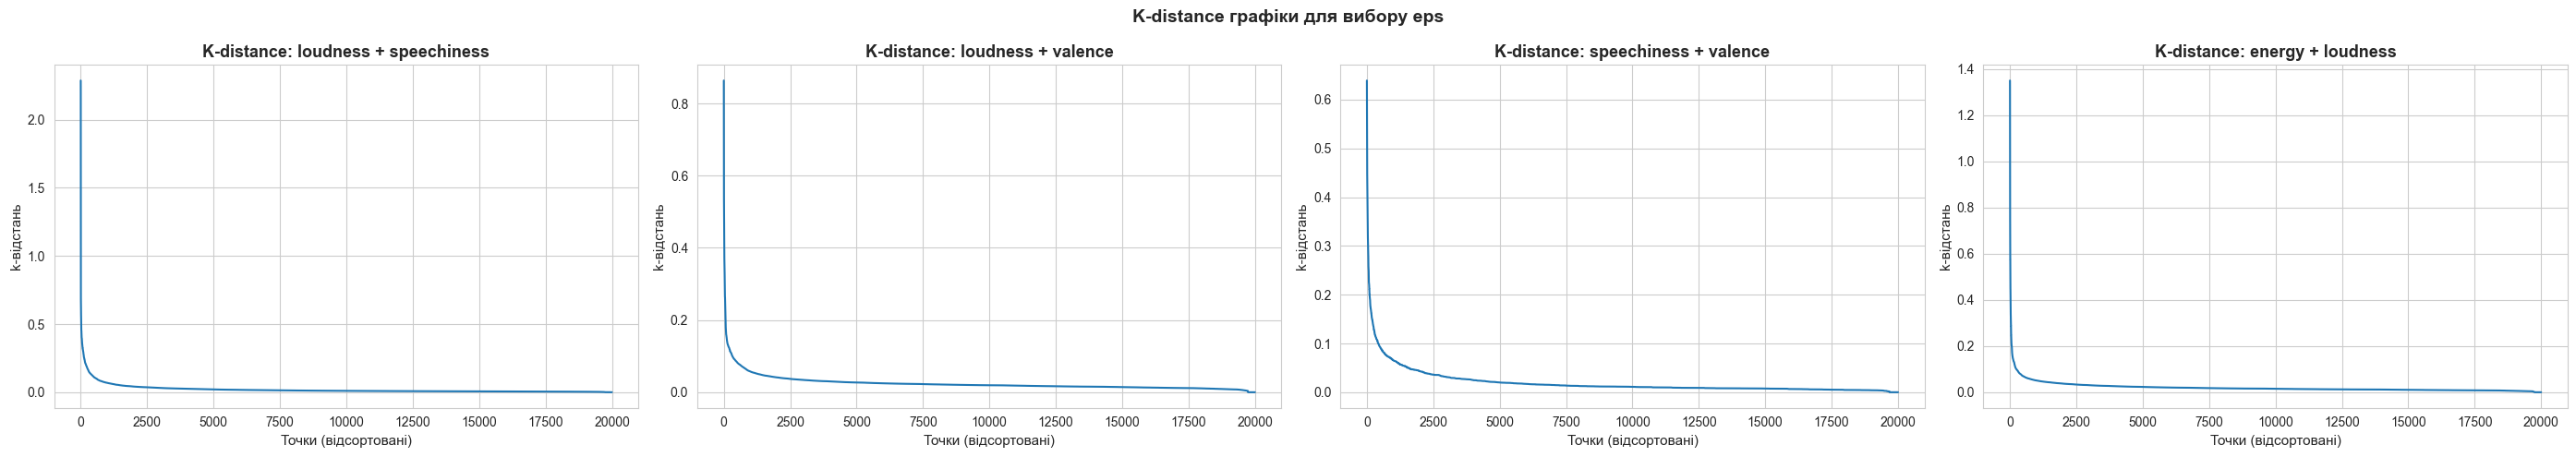

In [3]:
fig, axes = plt.subplots(1, N, figsize=(7 * N, 5))
if N == 1:
    axes = [axes]

for j, pair in enumerate(pairs):
    X_pair, _ = create_scaled(df_sub, pair)
    X_arr = X_pair.values
    distances = compute_k_distances(X_arr)
    plot_k_distance(distances, f'K-distance: {pair[0]} + {pair[1]}', ax=axes[j])

plt.suptitle('K-distance графіки для вибору eps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.2 Підбір eps (Grid Search)

In [4]:
eps_range_2d = np.arange(0.3, 2.5, 0.2)

pair_results = {}
for pair in pairs:
    X_pair, _ = create_scaled(df_sub, pair)
    X_arr = X_pair.values
    best_eps, best_sil, res_df = find_best_dbscan_eps(X_arr, eps_range_2d, DBSCAN_MIN_SAMPLES)
    pair_results[f'{pair[0]} + {pair[1]}'] = (best_eps, best_sil, res_df)
    print(f"\n{pair[0]} + {pair[1]}:")
    print(res_df.to_string(index=False))
    print(f"\u2192 Найкращий eps={best_eps}, Silhouette={best_sil:.4f}")


loudness + speechiness:
 eps  n_clusters  noise_pct  silhouette
 0.3           2        0.6      0.8217
 0.5           3        0.2      0.7502
 0.7           1        0.0     -1.0000
 0.9           1        0.0     -1.0000
 1.1           1        0.0     -1.0000
 1.3           1        0.0     -1.0000
 1.5           1        0.0     -1.0000
 1.7           1        0.0     -1.0000
 1.9           1        0.0     -1.0000
 2.1           1        0.0     -1.0000
 2.3           1        0.0     -1.0000
→ Найкращий eps=0.3, Silhouette=0.8217



loudness + valence:
 eps  n_clusters  noise_pct  silhouette
 0.3           1        0.2          -1
 0.5           1        0.1          -1
 0.7           1        0.0          -1
 0.9           1        0.0          -1
 1.1           1        0.0          -1
 1.3           1        0.0          -1
 1.5           1        0.0          -1
 1.7           1        0.0          -1
 1.9           1        0.0          -1
 2.1           1        0.0          -1
 2.3           1        0.0          -1
→ Найкращий eps=0.3, Silhouette=-1.0000



speechiness + valence:
 eps  n_clusters  noise_pct  silhouette
 0.3           2        0.5      0.8058
 0.5           2        0.1      0.8001
 0.7           1        0.0     -1.0000
 0.9           1        0.0     -1.0000
 1.1           1        0.0     -1.0000
 1.3           1        0.0     -1.0000
 1.5           1        0.0     -1.0000
 1.7           1        0.0     -1.0000
 1.9           1        0.0     -1.0000
 2.1           1        0.0     -1.0000
 2.3           1        0.0     -1.0000
→ Найкращий eps=0.3, Silhouette=0.8058



energy + loudness:
 eps  n_clusters  noise_pct  silhouette
 0.3           2        0.3      0.4307
 0.5           1        0.1     -1.0000
 0.7           1        0.1     -1.0000
 0.9           1        0.0     -1.0000
 1.1           1        0.0     -1.0000
 1.3           1        0.0     -1.0000
 1.5           1        0.0     -1.0000
 1.7           1        0.0     -1.0000
 1.9           1        0.0     -1.0000
 2.1           1        0.0     -1.0000
 2.3           1        0.0     -1.0000
→ Найкращий eps=0.3, Silhouette=0.4307


## 8.3 Кластеризація пар та 2D-візуалізація

loudness + speechiness: eps=0.3, кластерів=2, шум=0.6%


loudness + valence: eps=0.3, кластерів=1, шум=0.2%


speechiness + valence: eps=0.3, кластерів=2, шум=0.5%


energy + loudness: eps=0.3, кластерів=2, шум=0.3%


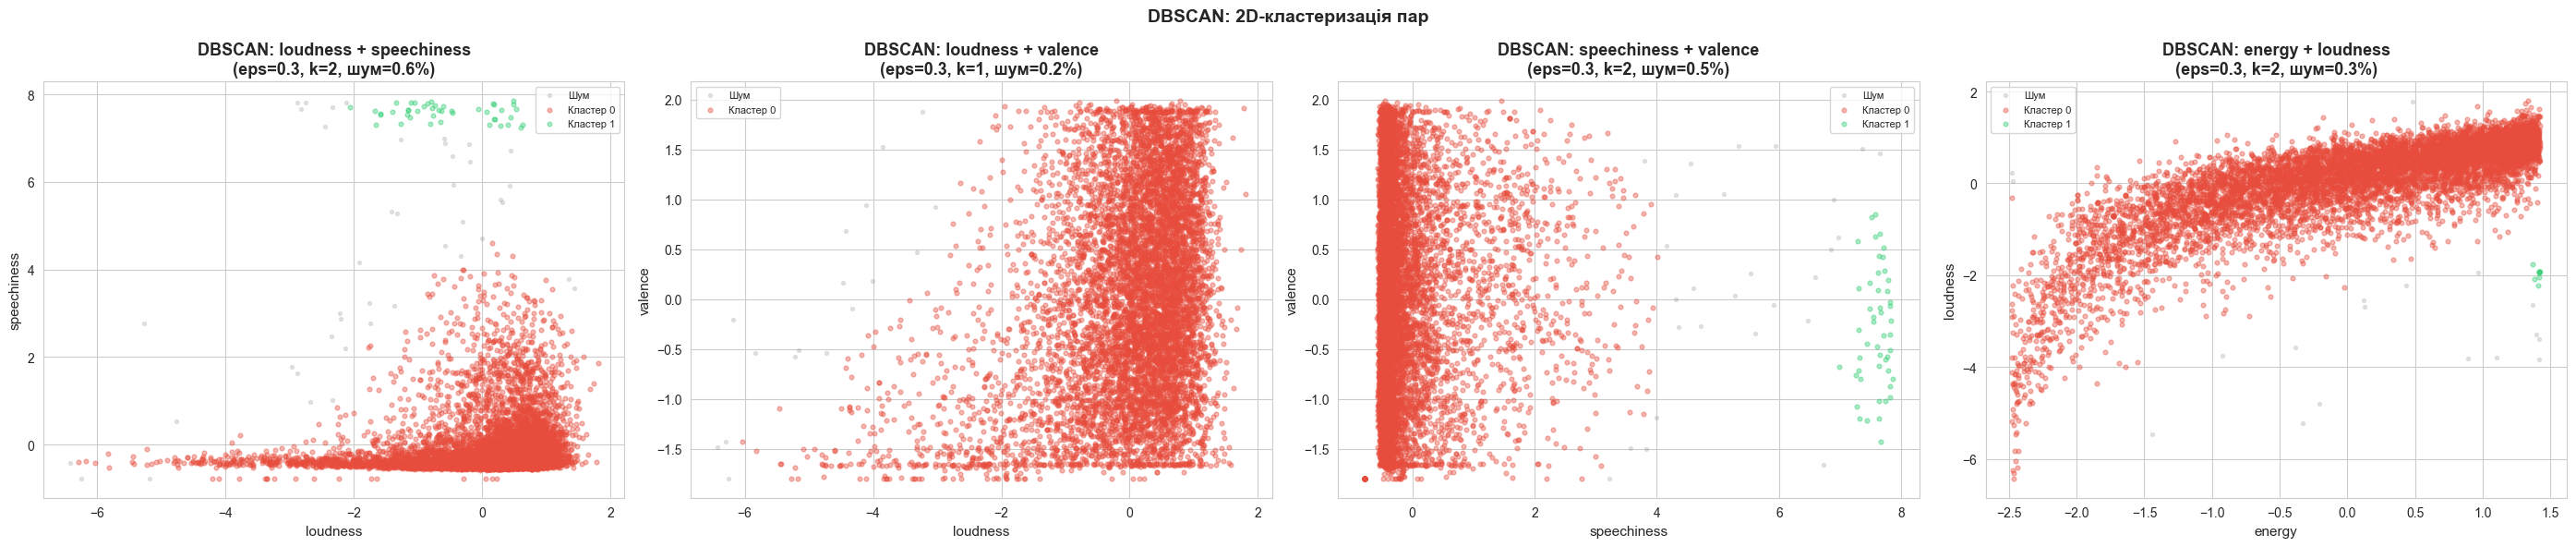

In [5]:
results = []
pair_labels = {}
fig, axes = plt.subplots(1, N, figsize=(7 * N, 6))
if N == 1:
    axes = [axes]

for i, pair in enumerate(pairs):
    pair_name = f'{pair[0]} + {pair[1]}'
    X_pair, _ = create_scaled(df_sub, pair)
    X_arr = X_pair.values
    best_eps = pair_results[pair_name][0]

    start = time.time()
    labels, model = run_dbscan(X_arr, best_eps, DBSCAN_MIN_SAMPLES)
    elapsed = time.time() - start

    pair_labels[i] = labels

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    metrics = compute_metrics(X_arr, labels)
    results.append(build_results_row('DBSCAN', pair_name, n_clusters, metrics, elapsed))

    plot_cluster_scatter_2d(X_arr, labels, pair,
                           f'DBSCAN: {pair_name}\n(eps={best_eps}, k={n_clusters}, шум={noise_pct:.1f}%)',
                           ax=axes[i], noise_label=-1)

    print(f"{pair_name}: eps={best_eps}, кластерів={n_clusters}, шум={noise_pct:.1f}%")

plt.suptitle('DBSCAN: 2D-кластеризація пар', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.4 Жанровий склад кластерів

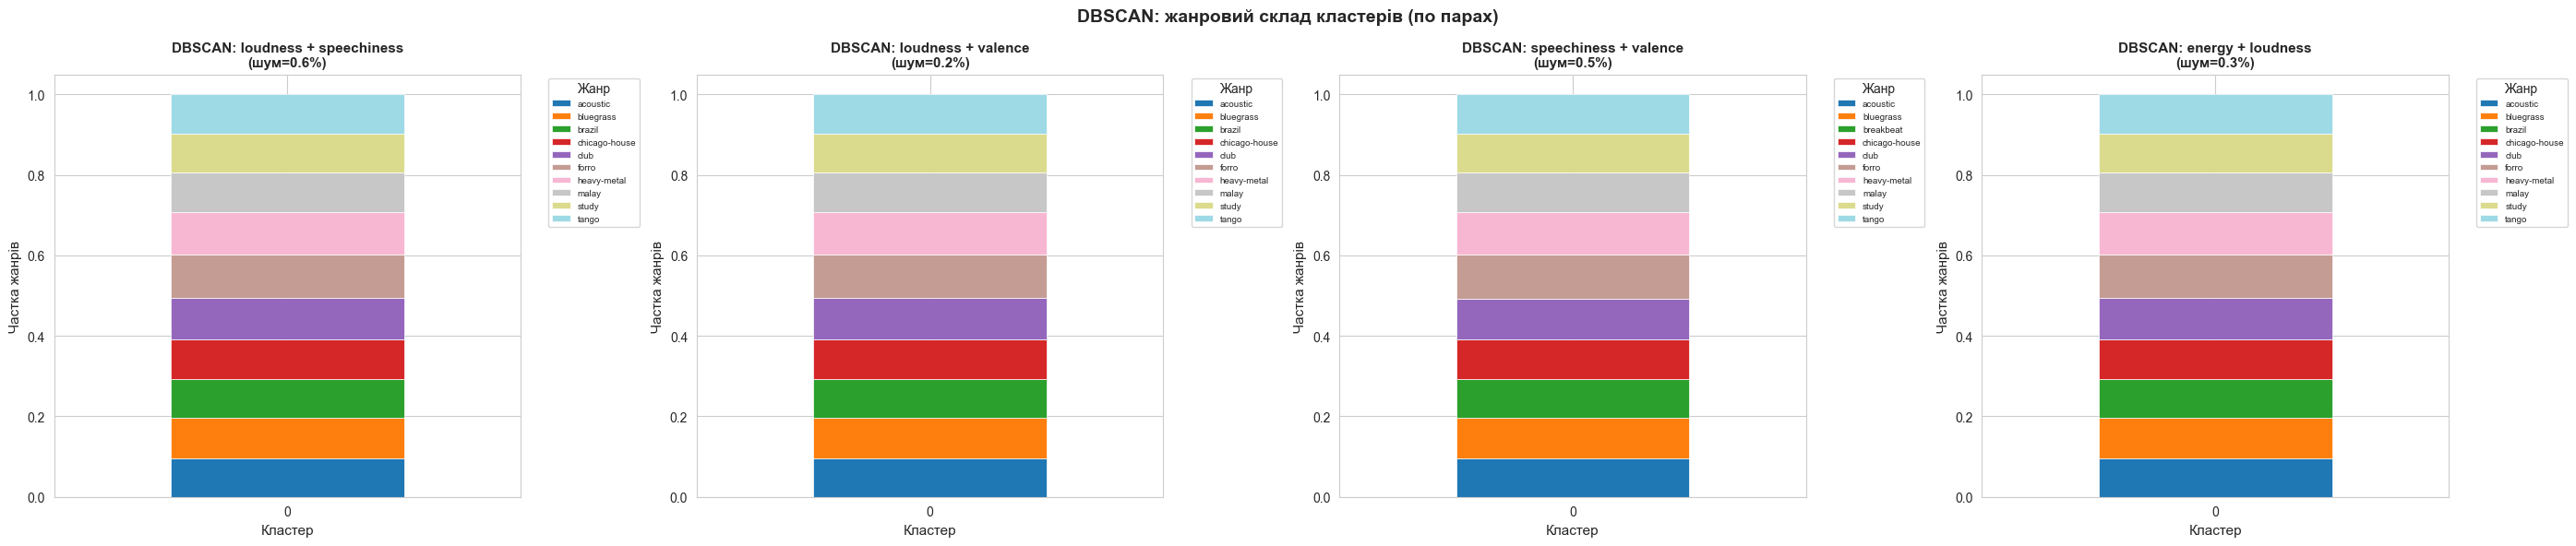

In [6]:
n_pairs = len(pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(7 * n_pairs, 6))
if n_pairs == 1:
    axes = [axes]

for i, pair in enumerate(pairs):
    pair_name = f'{pair[0]} + {pair[1]}'
    labels = pair_labels[i]

    df_copy = df_sub.copy()
    df_copy['cluster'] = labels

    df_no_noise = df_copy[df_copy['cluster'] != -1]
    top_genres = df_no_noise[GENRE_COL].value_counts().head(10).index
    df_genre = df_no_noise[df_no_noise[GENRE_COL].isin(top_genres)]

    ct = pd.crosstab(df_genre['cluster'], df_genre[GENRE_COL])
    ct_pct = ct.div(ct.sum(axis=1), axis=0)

    ct_pct.plot(kind='bar', stacked=True, ax=axes[i], colormap='tab20',
               edgecolor='white', linewidth=0.5)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    axes[i].set_xlabel('Кластер', fontsize=11)
    axes[i].set_ylabel('Частка жанрів', fontsize=11)
    axes[i].set_title(f'DBSCAN: {pair_name}\n(шум={noise_pct:.1f}%)',
                      fontsize=11, fontweight='bold')
    axes[i].legend(title='Жанр', bbox_to_anchor=(1.05, 1),
                   loc='upper left', fontsize=7)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.suptitle('DBSCAN: жанровий склад кластерів (по парах)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
save_results(results, 'results_dbscan.csv')
pd.DataFrame(results)

Результати збережено: F:\University\Магістр\Data Mining\Lab2-Data-Mining-2026\results\results_dbscan.csv


,algorithm,pair,k,silhouette,davies_bouldin,time_sec
0,DBSCAN,loudness + speechiness,2,0.821728,0.217009,1.0582
1,DBSCAN,loudness + valence,1,NaN,NaN,0.4920
2,DBSCAN,speechiness + valence,2,0.805813,0.216633,0.8540
3,DBSCAN,energy + loudness,2,0.430729,0.568604,0.7831


## Підсумок

**DBSCAN** — алгоритм кластеризації на основі щільності, що знаходить кластери довільної форми.

**Переваги:**
- Не потребує задання кількості кластерів k наперед
- Здатний виявляти кластери довільної форми (не лише сферичні)
- Автоматично визначає шумові точки (noise/викиди)
- Стійкий до викидів у даних

**Недоліки:**
- Чутливий до вибору параметрів eps та min_samples
- Погано працює з кластерами різної щільності
- У високовимірних просторах поняття щільності стає менш інформативним

**Результати:** DBSCAN автоматично визначив кількість кластерів та виокремив шумові точки. K-distance графіки допомогли обрати оптимальне значення eps, а Grid Search дозволив знайти найкращі параметри за Silhouette Score.